In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
pd.set_option('display.max_columns', None)

In [35]:
df = pd.read_csv('/Users/garvit/Desktop/NestWise/Clean Data/gurgaon_properties_outlier_treated.csv')

In [36]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,2400.0,Super Built up area 2400(222.97 sq.m.)Carpet a...,4.0,5.0,3+,6.0,East,Moderately Old,2400.0,NaN,1850.0,0,1,0,0,0,1,95
1,flat,capital residences 360,sector 70a,1.69,8553.0,1976.0,Super Built up area 1976(183.58 sq.m.)Built Up...,3.0,3.0,3+,8.0,North-East,New Property,1976.0,1900.0,1650.0,0,1,0,0,0,0,165
2,flat,emaar palm premier,sector 77,2.10,10500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3.0,4.0,3+,11.0,NaN,New Property,2000.0,1600.0,1500.0,0,1,0,0,0,1,129
3,flat,m3m merlin3.,sector 67,2.65,12946.0,2047.0,Super Built up area 2047(190.17 sq.m.)Built Up...,3.0,3.0,3,0.0,North-East,Relatively New,2047.0,1900.0,1700.0,0,0,0,0,1,1,174
4,flat,dnha group housing society,manesar,0.75,4518.0,1660.0,Super Built up area 1660(154.22 sq.m.),3.0,2.0,2,5.0,NaN,Moderately Old,1660.0,NaN,NaN,0,0,0,0,0,0,0


In [37]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1019
agePossession             0
super_built_up_area    1692
built_up_area          1973
carpet_area            1729
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

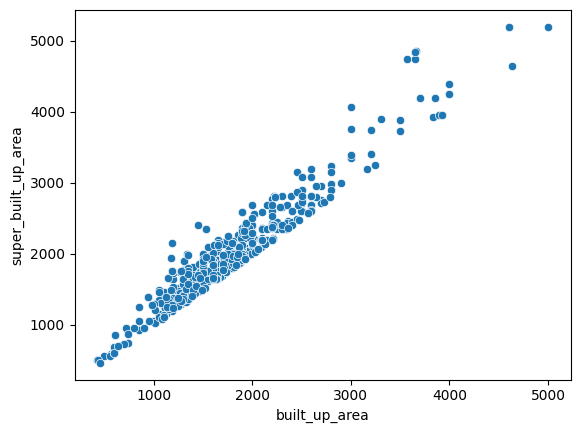

In [38]:
sns.scatterplot(x = df['built_up_area'],y = df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

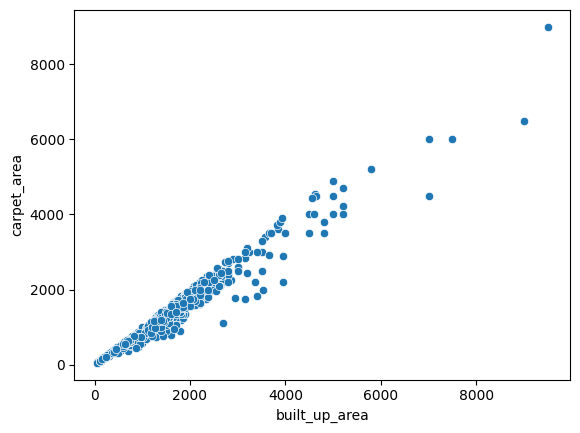

In [40]:
sns.scatterplot(x = df['built_up_area'],y = df['carpet_area'])

In [41]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3564    False
3565    False
3566    False
3567    False
3568    False
Length: 3569, dtype: bool

In [42]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [43]:
all_present_df.shape

(531, 23)

In [44]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [45]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [46]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [47]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [48]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,2400.0,Super Built up area 2400(222.97 sq.m.)Carpet a...,4.0,5.0,3+,6.0,East,Moderately Old,2400.0,NaN,1850.0,0,1,0,0,0,1,95
5,flat,godrej nature plus,sector 33 road,1.40,9333.0,1500.0,Super Built up area 1500(139.35 sq.m.)Carpet a...,2.0,2.0,3,14.0,NaN,Under Construction,1500.0,NaN,1385.0,0,0,0,0,0,0,67
14,flat,bestech park view city4.,sector 48,1.78,10023.0,1776.0,Super Built up area 1776(165 sq.m.)Carpet area...,3.0,4.0,2,5.0,NaN,Relatively New,1776.0,NaN,1300.0,1,0,0,1,0,0,53
31,flat,breez global heights4.,sohna road road,0.40,6421.0,623.0,Super Built up area 623(57.88 sq.m.)Carpet are...,2.0,2.0,1,4.0,North-East,New Property,623.0,NaN,599.0,0,0,0,0,0,0,49
46,flat,ss almeria,sector 84,1.50,7500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Carpet a...,3.0,3.0,3,2.0,NaN,New Property,2000.0,NaN,1700.0,0,1,0,0,0,0,108


In [49]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

In [50]:
df.update(sbc_df)

In [51]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1019
agePossession             0
super_built_up_area    1692
built_up_area          1552
carpet_area            1729
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [52]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [53]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,flat,dnha group housing society,manesar,0.75,4518.0,1660.0,Super Built up area 1660(154.22 sq.m.),3.0,2.0,2,5.0,NaN,Moderately Old,1660.0,NaN,NaN,0,0,0,0,0,0,0
6,flat,godrej summit3.,sector 104,0.75,5910.0,1269.0,Super Built up area 1269(117.89 sq.m.),2.0,2.0,3,6.0,East,Relatively New,1269.0,NaN,NaN,0,0,0,0,1,0,79
7,flat,signature global park4.,sohna road road,0.67,5537.0,1210.0,Super Built up area 1210(112.41 sq.m.),2.0,2.0,3,4.0,North-East,Relatively New,1210.0,NaN,NaN,0,0,0,1,0,0,127
8,flat,indiabulls enigma,sector 110,3.49,10265.0,3400.0,Super Built up area 3400(315.87 sq.m.),4.0,5.0,3,7.0,North-West,Relatively New,3400.0,NaN,NaN,0,1,0,0,0,0,165
9,flat,smart world gems,sector 89,0.86,7797.0,1103.0,Super Built up area 1103(102.47 sq.m.),2.0,3.0,3,4.0,NaN,Under Construction,1103.0,NaN,NaN,0,0,0,0,0,0,45


In [54]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df

In [55]:
df.update(sb_df)

In [56]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1019
agePossession             0
super_built_up_area    1692
built_up_area           676
carpet_area            1729
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [57]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [58]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
12,flat,bestech park view residency3.,sector 2,0.56,8550.0,655.0,Carpet area: 650 (60.39 sq.m.),1.0,1.0,2,7.0,South-West,Moderately Old,NaN,NaN,650.0,0,0,0,0,0,0,92
16,flat,signature global city 37d ph 2,sector 37d,1.07,8237.0,1299.0,Carpet area: 1305 (121.24 sq.m.),3.0,3.0,2,2.0,North-East,Under Construction,NaN,NaN,1305.0,0,0,0,0,0,0,86
17,flat,aipl zen residences,sector 70a,1.25,9905.0,1262.0,Carpet area: 1262 (117.24 sq.m.),2.0,2.0,2,19.0,NaN,New Property,NaN,NaN,1262.0,0,0,0,0,0,0,42
20,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2.0,2.0,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82
28,house,emaar mgf marbella,sector 66,19.00,35185.0,5400.0,Plot area 9000(836.13 sq.m.)Carpet area: 6000 ...,5.0,6.0,3+,3.0,North-East,Relatively New,NaN,NaN,6000.0,0,1,1,1,0,1,110


In [59]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_ar

In [60]:
df.update(c_df)

In [61]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1019
agePossession             0
super_built_up_area    1692
built_up_area             0
carpet_area            1729
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

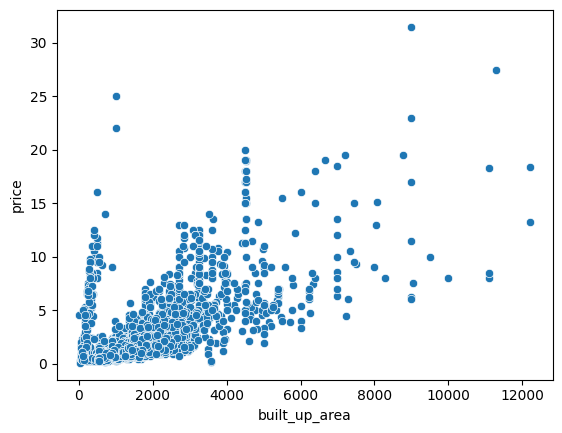

In [64]:
sns.scatterplot(x= df['built_up_area'],y = df['price'])

In [65]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [66]:
anamoly_df.sample(5)

,price,area,built_up_area
886,4.60,1287.0,1426.0
589,2.55,194.0,215.0
2514,2.80,1867.0,1654.0
2779,4.75,1485.0,1700.0
772,3.10,1550.0,1548.0


In [67]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [68]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

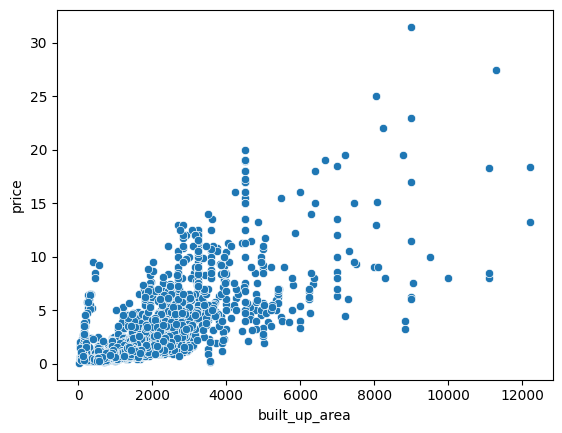

In [70]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [72]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area'],inplace=True)

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,NaN,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,NaN,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,NaN,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,North-West,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,North-East,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [73]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1019
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [74]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
63,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
663,house,independent,sector 26,4.60,12202.0,4.0,4.0,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,0,28
801,house,independent,sector 2,5.60,17284.0,8.0,6.0,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
877,house,independent,sector 4,4.12,8898.0,2.0,1.0,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
1049,house,ansal sushant lok plots,sector 43,3.30,26613.0,1.0,1.0,0,NaN,NaN,Under Construction,1240.0,0,0,0,0,0,0,0
1072,house,ansal sushant lok,sector 43,10.50,27926.0,4.0,4.0,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59
1139,house,independent,sector 7,6.50,15046.0,3.0,2.0,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
1350,flat,experion heartsong,dwarka expressway,1.08,6150.0,3.0,3.0,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
1539,house,independent,sector 25,13.00,45775.0,6.0,8.0,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
1958,house,independent,sector 3,1.50,102740.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0


In [75]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [76]:
df['floorNum'].fillna(2.0,inplace=True)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_6843/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [77]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1019
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [78]:
1011/df.shape[0]

0.283272625385262

### facing

<Axes: ylabel='count'>

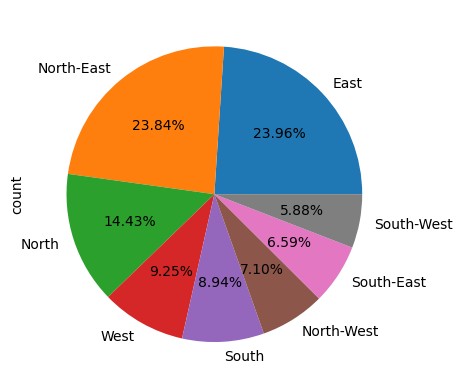

In [79]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [80]:
df.drop(columns=['facing'],inplace=True)

In [81]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1748,flat,tulip violet4.,sector 69,1.19,8815.0,2.0,3.0,1,0.0,Relatively New,1500.00,1,0,0,0,0,0,174
1121,flat,hsiidc sidco aravali,manesar,0.91,3516.0,3.0,3.0,3+,8.0,Moderately Old,1900.00,0,1,0,0,0,0,23
950,flat,ats tourmaline3.,sector 109,1.65,7674.0,3.0,3.0,3+,16.0,Relatively New,1946.00,0,1,0,0,0,1,49
1245,flat,experion the heartsong3.,sector 108,3.00,18394.0,4.0,5.0,3+,2.0,Relatively New,2204.25,0,1,0,0,0,2,149
2976,flat,sare homes,sector 92,0.58,4099.0,3.0,3.0,3,3.0,New Property,1281.00,0,0,0,0,0,0,54


In [82]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [83]:
df.drop(index=[2536],inplace=True)

In [84]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [85]:
df['agePossession'].value_counts()

agePossession
Relatively New        1609
New Property           561
Moderately Old         549
Old Property           293
Undefined              289
Under Construction     267
Name: count, dtype: int64

In [86]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
10,house,surendra homes dayaindependentd colony,sector 6,0.75,156250.0,4.0,4.0,2,1.0,Undefined,480.0,0,0,0,0,0,0,0
45,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,2.0,2.0,2,14.0,Undefined,915.0,0,0,0,0,0,0,0
48,flat,vatika inxt floors,sector 82a,0.75,7500.0,2.0,2.0,2,1.0,Undefined,1000.0,0,0,0,0,0,0,0
84,flat,satya element one,sector 49,0.80,11111.0,1.0,1.0,1,0.0,Undefined,720.0,0,0,0,0,0,0,0
85,house,independent,sector 13,0.62,36257.0,6.0,6.0,0,3.0,Undefined,192.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3531,house,independent,sector 4,0.70,66667.0,3.0,3.0,0,1.0,Undefined,117.0,0,0,0,0,0,0,0
3546,house,independent,sector 2,0.70,77778.0,1.0,1.0,0,1.0,Undefined,900.0,0,0,0,0,0,0,0
3554,house,independent,sector 37d,1.16,75325.0,1.0,1.0,0,1.0,Undefined,1535.0,0,0,0,0,0,0,0
3560,flat,emaar mgf emerald floors,sector 65,2.60,15758.0,3.0,3.0,3+,3.0,Undefined,1650.0,0,0,0,0,0,0,0


In [87]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [88]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [89]:
df['agePossession'].value_counts()

agePossession
Relatively New        1718
New Property           595
Moderately Old         593
Old Property           326
Under Construction     279
Undefined               57
Name: count, dtype: int64

In [90]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [91]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [92]:
df['agePossession'].value_counts()

agePossession
Relatively New        1735
Moderately Old         600
New Property           596
Old Property           335
Under Construction     281
Undefined               21
Name: count, dtype: int64

In [93]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [94]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [95]:
df['agePossession'].value_counts()

agePossession
Relatively New        1739
Moderately Old         617
New Property           596
Old Property           335
Under Construction     281
Name: count, dtype: int64

In [96]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [97]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [98]:
df.shape

(3568, 18)